In [1]:
import sys

print(sys.version)
print(sys.executable)

3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
c:\Users\Usuario\Documents\respiratory-rate-ppg\.venv\Scripts\python.exe


In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt 


In [2]:
fs = 100
duration = 30
t=np.arange(0, duration, 1/100)

print(f"número de muestras: {+ len(t)}")

número de muestras: 3000


In [3]:
HR = 70
RR = 15

f_hr = HR / 60
f_rr = RR / 60

print(f"Frecuencia cardíaca: {f_hr:.2f} Hz")
print(f"Frecuencia respiratoria: {f_rr:.2f} Hz")

Frecuencia cardíaca: 1.17 Hz
Frecuencia respiratoria: 0.25 Hz


In [26]:
respiration = 1 + 0.20 * np.sin(2* np.pi * f_rr * t)
cardiac = np.sin(2* np.pi * f_hr * t)
ppg = respiration * cardiac

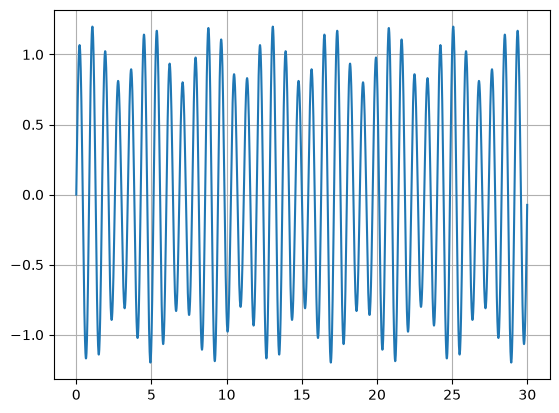

In [11]:
#plt.figure(figsize=(12, 4))
#plt.xlabel("Tiempo")
#plt.ylabel("Amplitud")
#plt.title("PPG sintética")
plt.plot(t, ppg)
plt.grid()
plt.show()

In [13]:
fft = np.fft.fft(ppg)
print(fft[:5])
frequencies = np.fft.fftfreq(len(ppg), 1/fs)
positive = frequencies >= 0
frequencies_positive = frequencies[positive]
fft_positive = np.abs(fft[positive])

[ 5.14406057e-14+0.j          3.03828552e-14+0.07354151j
 -5.37113925e-14+0.1479154j   4.06246145e-14+0.22397909j
  2.93261058e-13+0.30264153j]


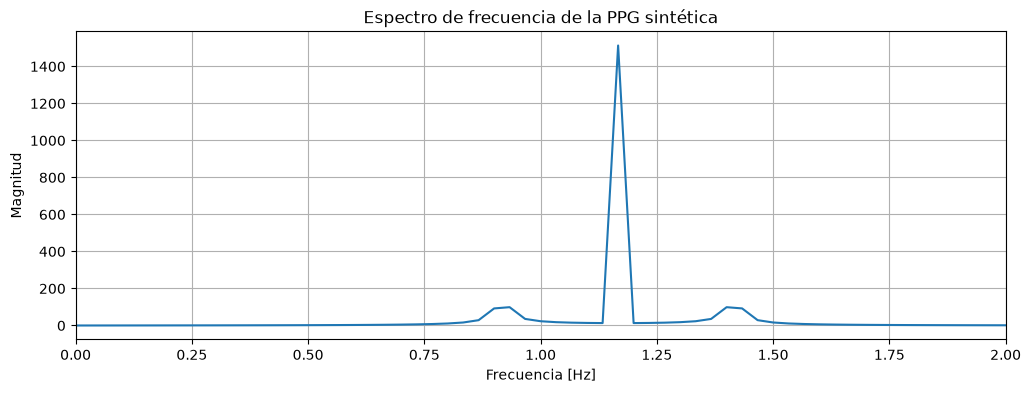

In [14]:
plt.figure(figsize=(12, 4))

plt.plot(frequencies_positive, fft_positive)

plt.xlim(0, 2)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de frecuencia de la PPG sintética")

plt.grid()
plt.show()

In [15]:
indice_pico = np.argmax(fft_positive)
print(indice_pico)
frecuencia_pico = frequencies_positive[indice_pico]
print(frecuencia_pico)

35
1.1666666666666667


In [16]:
rr_band = (frequencies_positive >= 0.10) & (frequencies_positive <= 0.50)
print(rr_band)

[False False False ... False False False]


In [17]:
fft_resp = np.fft.fft(respiration)

freq_resp = np.fft.fftfreq(
    len(respiration),
    1/fs
)

positive_resp = freq_resp >= 0

freq_resp_positive = freq_resp[positive_resp]
fft_resp_positive = np.abs(fft_resp[positive_resp])

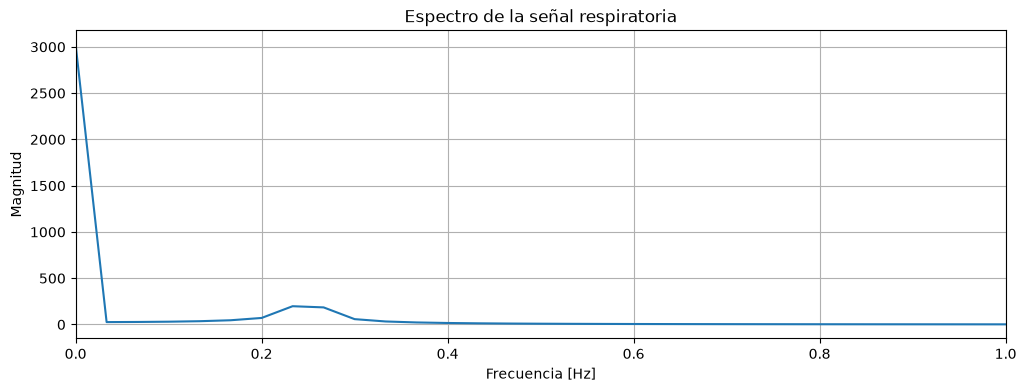

In [18]:
plt.figure(figsize=(12, 4))
plt.plot(freq_resp_positive, fft_resp_positive)
plt.xlim(0, 1)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de la señal respiratoria")
plt.grid()
plt.show()

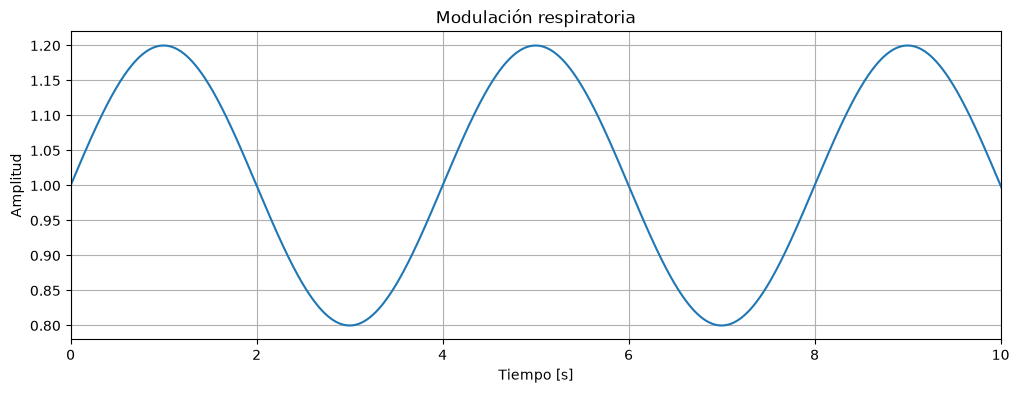

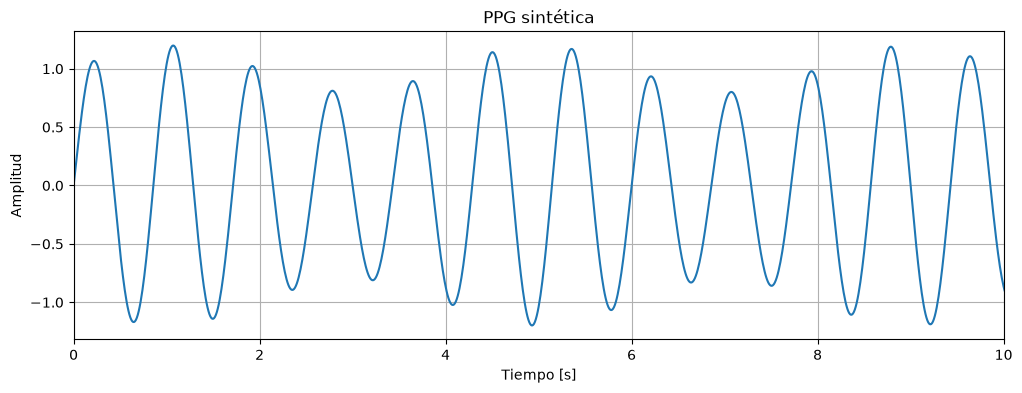

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(t, respiration)
plt.xlim(0, 10)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Modulación respiratoria")
plt.grid()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t, ppg)
plt.xlim(0, 10)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("PPG sintética")
plt.grid()
plt.show()

In [24]:
from scipy.signal import find_peaks

In [27]:
peaks, properties = find_peaks(
    ppg,
    distance=int(fs * 0.5)
)

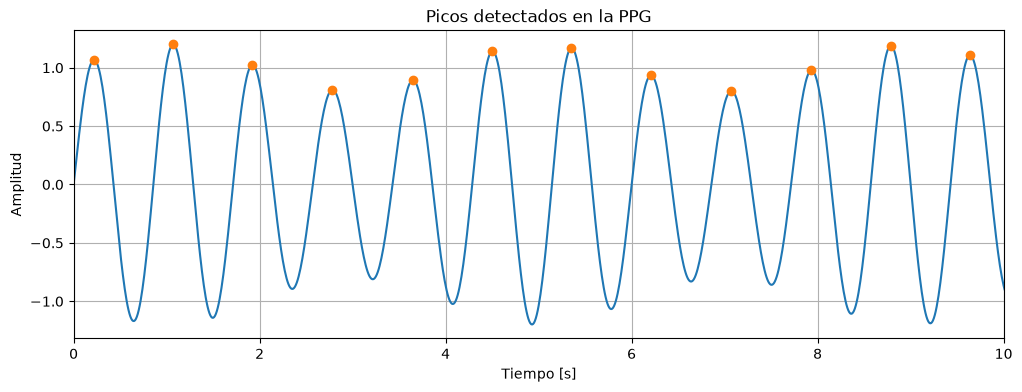

In [29]:
plt.figure(figsize=(12, 4))

plt.plot(t, ppg)
plt.plot(t[peaks], ppg[peaks], "o")

plt.xlim(0, 10)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Picos detectados en la PPG")
plt.grid()

plt.show()

In [48]:
amplitudes = ppg[peaks]
print(amplitudes[:10])

[1.06681099 1.19872646 1.02304391 0.81111174 0.89427304 1.14142136
 1.16892386 0.93475504 0.80116388 0.97799951]


In [30]:
peaks, properties = find_peaks(
    ppg,
    distance=int(fs * 0.5)
)

amplitudes = ppg[peaks]

In [31]:
peak_times = t[peaks]

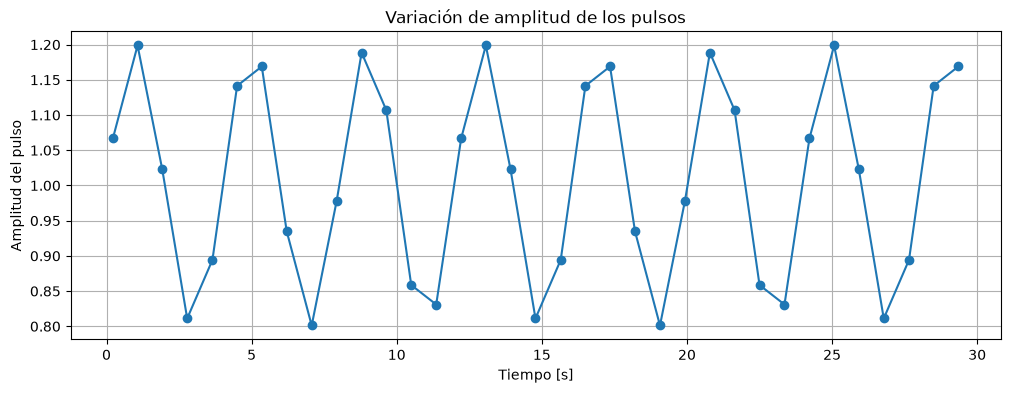

In [32]:
plt.figure(figsize=(12, 4))

plt.plot(peak_times, amplitudes, "o-")

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud del pulso")
plt.title("Variación de amplitud de los pulsos")
plt.grid()

plt.show()

In [33]:
fs_resp = 10

t_resp = np.arange(
    peak_times[0],
    peak_times[-1],
    1/fs_resp
)

In [34]:
amplitudes_interp = np.interp(
    t_resp,
    peak_times,
    amplitudes
)

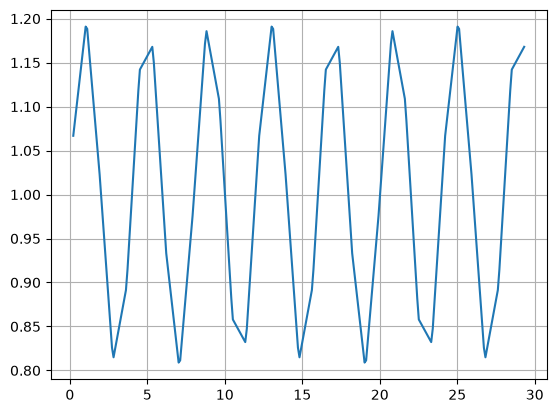

In [35]:
#plt.figure(figsize=(12, 4))

plt.plot(t_resp, amplitudes_interp)

#plt.xlabel("Tiempo [s]")
#plt.ylabel("Amplitud")
#plt.title("Señal respiratoria estimada mediante RIAV")
plt.grid()

plt.show()

In [36]:
fft_riav = np.fft.fft(amplitudes_interp)

In [37]:
frequencies_riav = np.fft.fftfreq(
    len(amplitudes_interp),
    1/fs_resp
)

In [38]:
positive_riav = frequencies_riav >= 0

frequencies_riav_positive = frequencies_riav[positive_riav]

fft_riav_positive = np.abs(
    fft_riav[positive_riav]
)

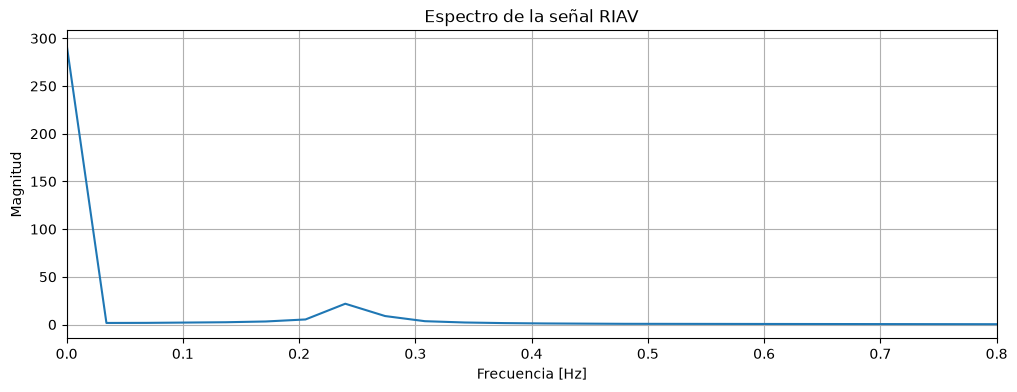

In [39]:
plt.figure(figsize=(12, 4))

plt.plot(
    frequencies_riav_positive,
    fft_riav_positive
)

plt.xlim(0, 0.8)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de la señal RIAV")

plt.grid()
plt.show()

In [52]:
indice_pico = np.argmax(fft_riav_positive)

frecuencia_rr = frequencies_riav_positive[indice_pico]

rr = frecuencia_rr * 60

print(f"Frecuencia respiratoria: {frecuencia_rr:.2f} Hz")
print(f"Frecuencia respiratoria: {rr:.1f} rpm")

Frecuencia respiratoria: 0.24 Hz
Frecuencia respiratoria: 14.4 rpm


In [44]:
amplitudes_centered = amplitudes_interp - np.mean(amplitudes_interp)

In [45]:
amplitudes_centered = amplitudes_interp - np.mean(amplitudes_interp)

fft_riav = np.fft.fft(amplitudes_centered)

In [46]:
frequencies_riav = np.fft.fftfreq(
    len(amplitudes_centered),
    1/fs_resp
)

positive_riav = frequencies_riav >= 0

frequencies_riav_positive = frequencies_riav[positive_riav]

fft_riav_positive = np.abs(
    fft_riav[positive_riav]
)

In [47]:
indice_pico = np.argmax(fft_riav_positive)

frecuencia_rr = frequencies_riav_positive[indice_pico]

rr = frecuencia_rr * 60

print(f"Frecuencia respiratoria: {frecuencia_rr:.2f} Hz")
print(f"Frecuencia respiratoria: {rr:.1f} rpm")

Frecuencia respiratoria: 0.24 Hz
Frecuencia respiratoria: 14.4 rpm


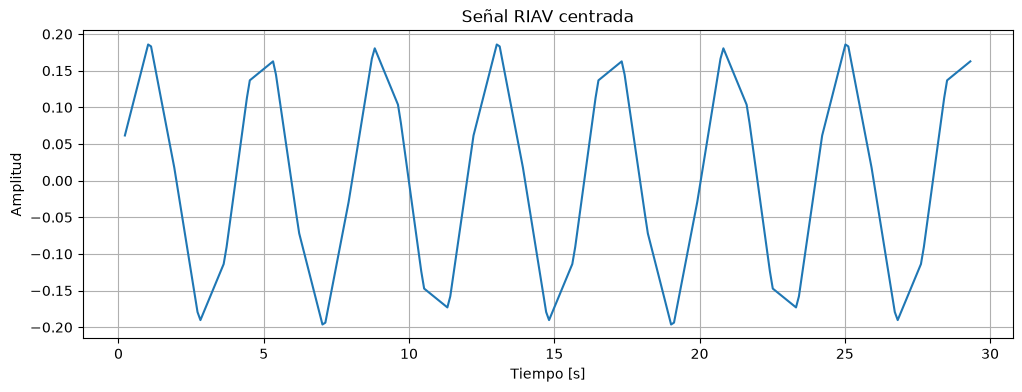

In [48]:
plt.figure(figsize=(12, 4))

plt.plot(t_resp, amplitudes_centered)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal RIAV centrada")
plt.grid()

plt.show()

In [49]:
frecuencia_rr = frequencies_riav_positive[indice_pico]
print(frecuencia_rr)

0.23972602739726026


In [50]:
indice_pico = np.argmax(fft_riav_positive)

In [51]:
rr_min = 6
rr_max = 30

f_min = rr_min / 60
f_max = rr_max / 60

rr_band = (
    (frequencies_riav_positive >= f_min) &
    (frequencies_riav_positive <= f_max)
)

frequencies_rr = frequencies_riav_positive[rr_band]
fft_rr = fft_riav_positive[rr_band]

indice_pico = np.argmax(fft_rr)

frecuencia_rr = frequencies_rr[indice_pico]

rr = frecuencia_rr * 60

print(f"Frecuencia respiratoria: {frecuencia_rr:.2f} Hz")
print(f"Frecuencia respiratoria: {rr:.1f} rpm")

Frecuencia respiratoria: 0.24 Hz
Frecuencia respiratoria: 14.4 rpm


In [53]:
duraciones = [10, 20, 30, 60]

for T in duraciones:
    N = fs_resp * T
    delta_f = fs_resp / N
    delta_rr = delta_f * 60

    print(f"Ventana: {T:2d} s | N: {N:4d} | Δf: {delta_f:.4f} Hz | ΔRR: {delta_rr:.1f} rpm")

Ventana: 10 s | N:  100 | Δf: 0.1000 Hz | ΔRR: 6.0 rpm
Ventana: 20 s | N:  200 | Δf: 0.0500 Hz | ΔRR: 3.0 rpm
Ventana: 30 s | N:  300 | Δf: 0.0333 Hz | ΔRR: 2.0 rpm
Ventana: 60 s | N:  600 | Δf: 0.0167 Hz | ΔRR: 1.0 rpm


In [54]:
duraciones = [10, 20, 30, 60]

for T in duraciones:

    N = int(fs_resp * T)

    señal = amplitudes_centered[:N]

    fft = np.fft.fft(señal)

    frequencies = np.fft.fftfreq(
        len(señal),
        1 / fs_resp
    )

    positive = frequencies >= 0

    frequencies_positive = frequencies[positive]
    fft_positive = np.abs(fft[positive])

    rr_band = (
        (frequencies_positive >= 0.10) &
        (frequencies_positive <= 0.50)
    )

    frequencies_rr = frequencies_positive[rr_band]
    fft_rr = fft_positive[rr_band]

    indice_pico = np.argmax(fft_rr)

    frecuencia_rr = frequencies_rr[indice_pico]

    rr = frecuencia_rr * 60

    print(f"Ventana: {T:2d} s → RR estimada: {rr:.1f} rpm")

Ventana: 10 s → RR estimada: 12.0 rpm
Ventana: 20 s → RR estimada: 15.0 rpm
Ventana: 30 s → RR estimada: 14.4 rpm
Ventana: 60 s → RR estimada: 14.4 rpm


In [55]:
print(f"Muestras disponibles: {len(amplitudes_centered)}")
print(f"Duración disponible: {len(amplitudes_centered) / fs_resp:.1f} s")

Muestras disponibles: 292
Duración disponible: 29.2 s


In [57]:
duraciones = [10, 20, 30, 60]

for T in duraciones:

    N = int(fs_resp * T)

    if len(amplitudes_centered) < N:
        print(f"Ventana: {T} s → muestras insuficientes")
        continue

    señal = amplitudes_centered[:N]

    fft = np.fft.fft(señal)

    frequencies = np.fft.fftfreq(
        len(señal),
        1 / fs_resp
    )

    positive = frequencies >= 0

    frequencies_positive = frequencies[positive]
    fft_positive = np.abs(fft[positive])

    rr_band = (
        (frequencies_positive >= 0.10) &
        (frequencies_positive <= 0.50)
    )

    frequencies_rr = frequencies_positive[rr_band]
    fft_rr = fft_positive[rr_band]

    indice_pico = np.argmax(fft_rr)
    frecuencia_rr = frequencies_rr[indice_pico]
    rr = frecuencia_rr * 60

    print(f"Ventana: {T:2d} s → RR estimada: {rr:.1f} rpm")

Ventana: 10 s → RR estimada: 12.0 rpm
Ventana: 20 s → RR estimada: 15.0 rpm
Ventana: 30 s → muestras insuficientes
Ventana: 60 s → muestras insuficientes


In [58]:
ventana_s = 20
actualizacion_s = 2

N_ventana = int(fs_resp * ventana_s)
N_paso = int(fs_resp * actualizacion_s)

print(f"Muestras por ventana: {N_ventana}")
print(f"Muestras por actualización: {N_paso}")

Muestras por ventana: 200
Muestras por actualización: 20


In [59]:
ventanas = []

for inicio in range(
    0,
    len(amplitudes_centered) - N_ventana + 1,
    N_paso
):
    fin = inicio + N_ventana

    ventana = amplitudes_centered[inicio:fin]

    ventanas.append(ventana)

print(f"Número de ventanas: {len(ventanas)}")

Número de ventanas: 5


In [60]:
resultados_rr = []

for i, señal in enumerate(ventanas):

    fft = np.fft.fft(señal)

    frequencies = np.fft.fftfreq(
        len(señal),
        d=1 / fs_resp
    )

    positive = frequencies >= 0

    frequencies_positive = frequencies[positive]
    fft_positive = np.abs(fft[positive])

    rr_band = (
        (frequencies_positive >= 0.10) &
        (frequencies_positive <= 0.50)
    )

    frequencies_rr = frequencies_positive[rr_band]
    fft_rr = fft_positive[rr_band]

    indice_pico = np.argmax(fft_rr)

    frecuencia_rr = frequencies_rr[indice_pico]
    rr = frecuencia_rr * 60

    resultados_rr.append(rr)

    print(f"Ventana {i + 1}: RR estimada = {rr:.1f} rpm")

Ventana 1: RR estimada = 15.0 rpm
Ventana 2: RR estimada = 15.0 rpm
Ventana 3: RR estimada = 15.0 rpm
Ventana 4: RR estimada = 15.0 rpm
Ventana 5: RR estimada = 15.0 rpm


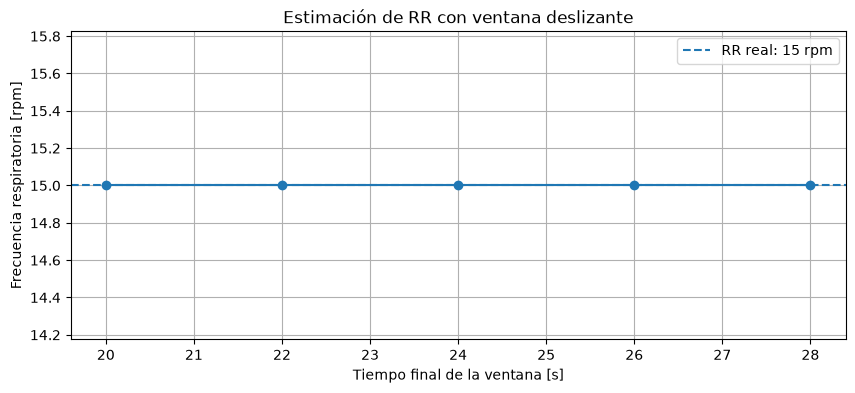

In [61]:
tiempos = [
    (i * N_paso + N_ventana) / fs_resp
    for i in range(len(resultados_rr))
]

plt.figure(figsize=(10, 4))
plt.plot(tiempos, resultados_rr, marker="o")
plt.axhline(y=15, linestyle="--", label="RR real: 15 rpm")

plt.xlabel("Tiempo final de la ventana [s]")
plt.ylabel("Frecuencia respiratoria [rpm]")
plt.title("Estimación de RR con ventana deslizante")
plt.grid()
plt.legend()
plt.show()

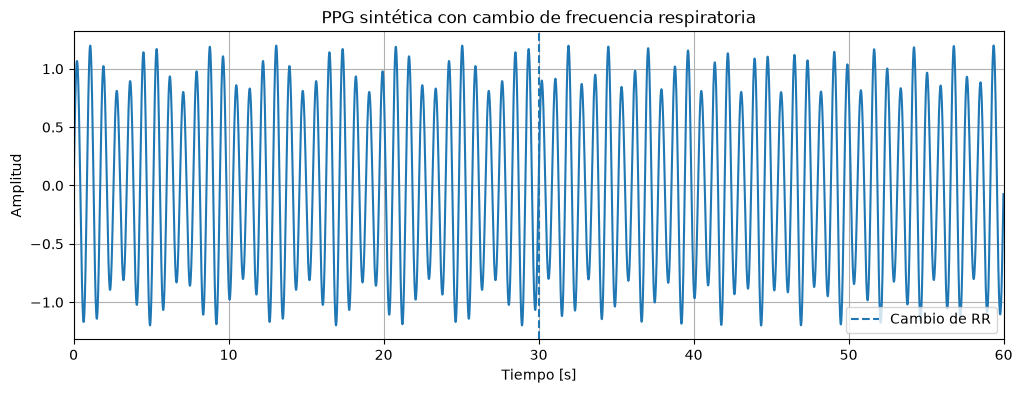

In [62]:
import numpy as np
import matplotlib.pyplot as plt

fs = 100
duration = 60

t = np.arange(0, duration, 1/fs)

HR = 70
f_hr = HR / 60

# La respiración cambia en el segundo 30
RR_1 = 15
RR_2 = 24
t_cambio = 30

# Fase respiratoria continua
fase_resp = np.zeros_like(t)

antes = t <= t_cambio
despues = t > t_cambio

fase_resp[antes] = 2 * np.pi * (RR_1 / 60) * t[antes]

fase_en_cambio = 2 * np.pi * (RR_1 / 60) * t_cambio

fase_resp[despues] = (
    fase_en_cambio
    + 2 * np.pi * (RR_2 / 60) * (t[despues] - t_cambio)
)

respiration = 1 + 0.20 * np.sin(fase_resp)
cardiac = np.sin(2 * np.pi * f_hr * t)

ppg = respiration * cardiac

plt.figure(figsize=(12, 4))
plt.plot(t, ppg)
plt.axvline(t_cambio, linestyle="--", label="Cambio de RR")
plt.xlim(0, 60)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("PPG sintética con cambio de frecuencia respiratoria")
plt.grid()
plt.legend()
plt.show()

In [63]:
from scipy.signal import find_peaks

# 1. Detectar los picos cardíacos
peaks, _ = find_peaks(ppg, distance=int(fs * 0.5))

peak_times = t[peaks]
amplitudes = ppg[peaks]

# 2. Interpolar las amplitudes a 10 Hz
fs_resp = 10

t_resp = np.arange(
    peak_times[0],
    peak_times[-1],
    1 / fs_resp
)

amplitudes_interp = np.interp(
    t_resp,
    peak_times,
    amplitudes
)

# 3. Configurar la ventana deslizante
ventana_s = 20
actualizacion_s = 2

N_ventana = int(fs_resp * ventana_s)
N_paso = int(fs_resp * actualizacion_s)

resultados_rr = []
tiempos_finales = []

# 4. Estimar RR en cada ventana
for inicio in range(
    0,
    len(amplitudes_interp) - N_ventana + 1,
    N_paso
):
    fin = inicio + N_ventana

    señal = amplitudes_interp[inicio:fin]

    # Eliminar la media de esta ventana
    señal = señal - np.mean(señal)

    # Calcular FFT
    fft = np.fft.fft(señal)
    frequencies = np.fft.fftfreq(
        len(señal),
        d=1 / fs_resp
    )

    # Conservar frecuencias no negativas
    positive = frequencies >= 0
    frequencies_positive = frequencies[positive]
    fft_positive = np.abs(fft[positive])

    # Buscar el pico en la banda respiratoria
    rr_band = (
        (frequencies_positive >= 0.10) &
        (frequencies_positive <= 0.50)
    )

    frequencies_rr = frequencies_positive[rr_band]
    fft_rr = fft_positive[rr_band]

    indice_pico = np.argmax(fft_rr)
    frecuencia_rr = frequencies_rr[indice_pico]
    rr = frecuencia_rr * 60

    resultados_rr.append(rr)
    tiempos_finales.append(t_resp[fin - 1])

# 5. Mostrar resultados
for tiempo, rr in zip(tiempos_finales, resultados_rr):
    print(f"Tiempo: {tiempo:5.1f} s | RR estimada: {rr:.1f} rpm")

Tiempo:  20.1 s | RR estimada: 15.0 rpm
Tiempo:  22.1 s | RR estimada: 15.0 rpm
Tiempo:  24.1 s | RR estimada: 15.0 rpm
Tiempo:  26.1 s | RR estimada: 15.0 rpm
Tiempo:  28.1 s | RR estimada: 15.0 rpm
Tiempo:  30.1 s | RR estimada: 15.0 rpm
Tiempo:  32.1 s | RR estimada: 15.0 rpm
Tiempo:  34.1 s | RR estimada: 15.0 rpm
Tiempo:  36.1 s | RR estimada: 15.0 rpm
Tiempo:  38.1 s | RR estimada: 15.0 rpm
Tiempo:  40.1 s | RR estimada: 15.0 rpm
Tiempo:  42.1 s | RR estimada: 24.0 rpm
Tiempo:  44.1 s | RR estimada: 24.0 rpm
Tiempo:  46.1 s | RR estimada: 24.0 rpm
Tiempo:  48.1 s | RR estimada: 24.0 rpm
Tiempo:  50.1 s | RR estimada: 24.0 rpm
Tiempo:  52.1 s | RR estimada: 24.0 rpm
Tiempo:  54.1 s | RR estimada: 24.0 rpm
Tiempo:  56.1 s | RR estimada: 24.0 rpm
Tiempo:  58.1 s | RR estimada: 24.0 rpm


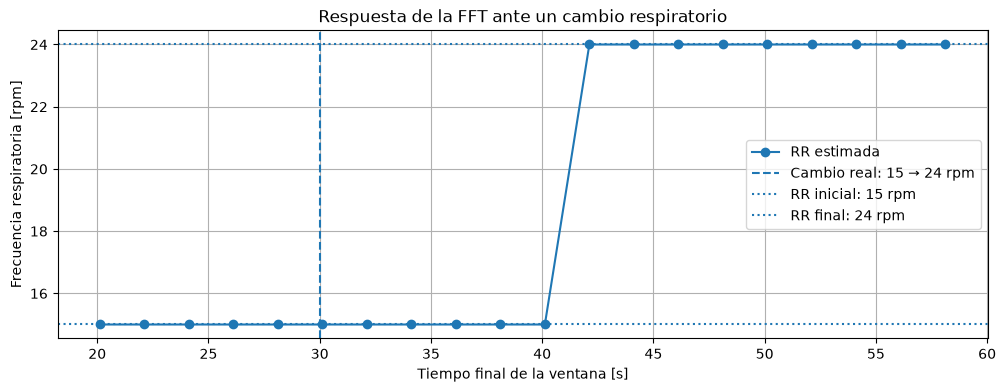

In [64]:
plt.figure(figsize=(12, 4))

plt.plot(
    tiempos_finales,
    resultados_rr,
    marker="o",
    label="RR estimada"
)

plt.axvline(
    t_cambio,
    linestyle="--",
    label="Cambio real: 15 → 24 rpm"
)

plt.axhline(15, linestyle=":", label="RR inicial: 15 rpm")
plt.axhline(24, linestyle=":", label="RR final: 24 rpm")

plt.xlabel("Tiempo final de la ventana [s]")
plt.ylabel("Frecuencia respiratoria [rpm]")
plt.title("Respuesta de la FFT ante un cambio respiratorio")
plt.grid()
plt.legend()
plt.show()

In [66]:
def estimar_rr_ventanas(
    señal_riav,
    fs_resp,
    ventana_s,
    actualizacion_s
):
    N_ventana = int(fs_resp * ventana_s)
    N_paso = int(fs_resp * actualizacion_s)

    resultados_rr = []
    tiempos_finales = []

    for inicio in range(
        0,
        len(señal_riav) - N_ventana + 1,
        N_paso
    ):
        fin = inicio + N_ventana
        señal = señal_riav[inicio:fin]

        # Eliminar la media de la ventana
        señal = señal - np.mean(señal)

        # Calcular FFT
        fft = np.fft.fft(señal)
        frecuencias = np.fft.fftfreq(
            len(señal),
            d=1 / fs_resp
        )

        # Conservar frecuencias no negativas
        positivo = frecuencias >= 0
        frecuencias = frecuencias[positivo]
        magnitudes = np.abs(fft[positivo])

        # Buscar el pico en la banda respiratoria
        banda = (
            (frecuencias >= 0.10) &
            (frecuencias <= 0.50)
        )

        frecuencias_rr = frecuencias[banda]
        magnitudes_rr = magnitudes[banda]

        indice_pico = np.argmax(magnitudes_rr)
        frecuencia_rr = frecuencias_rr[indice_pico]

        # Convertir Hz a respiraciones por minuto
        rr = frecuencia_rr * 60

        resultados_rr.append(rr)
        tiempos_finales.append(t_resp[fin - 1])

    return tiempos_finales, resultados_rr

In [67]:
configuraciones = [10, 20, 30]

resultados = {}

for ventana_s in configuraciones:

    tiempos, rr = estimar_rr_ventanas(
        señal_riav=amplitudes_interp,
        fs_resp=fs_resp,
        ventana_s=ventana_s,
        actualizacion_s=2
    )

    resultados[ventana_s] = (tiempos, rr)

    print(f"\nVentana de {ventana_s} segundos")

    for tiempo, estimacion in zip(tiempos, rr):
        print(
            f"Tiempo: {tiempo:5.1f} s | "
            f"RR estimada: {estimacion:.1f} rpm"
        )


Ventana de 10 segundos
Tiempo:  10.1 s | RR estimada: 12.0 rpm
Tiempo:  12.1 s | RR estimada: 12.0 rpm
Tiempo:  14.1 s | RR estimada: 12.0 rpm
Tiempo:  16.1 s | RR estimada: 12.0 rpm
Tiempo:  18.1 s | RR estimada: 12.0 rpm
Tiempo:  20.1 s | RR estimada: 12.0 rpm
Tiempo:  22.1 s | RR estimada: 12.0 rpm
Tiempo:  24.1 s | RR estimada: 12.0 rpm
Tiempo:  26.1 s | RR estimada: 12.0 rpm
Tiempo:  28.1 s | RR estimada: 12.0 rpm
Tiempo:  30.1 s | RR estimada: 12.0 rpm
Tiempo:  32.1 s | RR estimada: 18.0 rpm
Tiempo:  34.1 s | RR estimada: 18.0 rpm
Tiempo:  36.1 s | RR estimada: 18.0 rpm
Tiempo:  38.1 s | RR estimada: 24.0 rpm
Tiempo:  40.1 s | RR estimada: 24.0 rpm
Tiempo:  42.1 s | RR estimada: 24.0 rpm
Tiempo:  44.1 s | RR estimada: 24.0 rpm
Tiempo:  46.1 s | RR estimada: 24.0 rpm
Tiempo:  48.1 s | RR estimada: 24.0 rpm
Tiempo:  50.1 s | RR estimada: 24.0 rpm
Tiempo:  52.1 s | RR estimada: 24.0 rpm
Tiempo:  54.1 s | RR estimada: 24.0 rpm
Tiempo:  56.1 s | RR estimada: 24.0 rpm
Tiempo:  58.1 s 

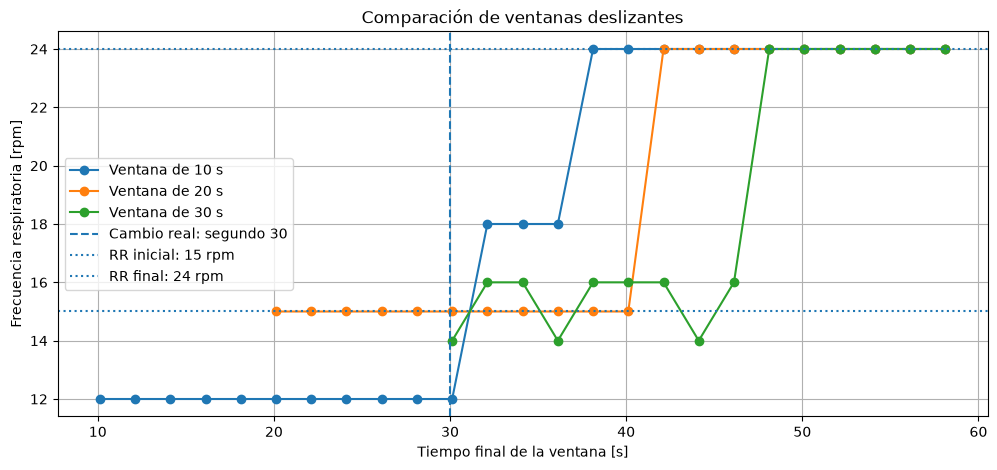

In [68]:
plt.figure(figsize=(12, 5))

for ventana_s, (tiempos, rr) in resultados.items():
    plt.plot(
        tiempos,
        rr,
        marker="o",
        label=f"Ventana de {ventana_s} s"
    )

plt.axvline(
    t_cambio,
    linestyle="--",
    label="Cambio real: segundo 30"
)

plt.axhline(15, linestyle=":", label="RR inicial: 15 rpm")
plt.axhline(24, linestyle=":", label="RR final: 24 rpm")

plt.xlabel("Tiempo final de la ventana [s]")
plt.ylabel("Frecuencia respiratoria [rpm]")
plt.title("Comparación de ventanas deslizantes")
plt.grid()
plt.legend()
plt.show()

In [69]:
import numpy as np

RR_inicial = 15
RR_final = 24
t_cambio = 30

tolerancia = 2
rr_min_deteccion = RR_final - tolerancia
rr_max_deteccion = RR_final + tolerancia

resumen = []

for ventana_s, (tiempos, rr) in resultados.items():

    tiempos = np.array(tiempos)
    rr = np.array(rr)

    # Error antes del cambio
    antes = tiempos <= t_cambio
    mae_antes = np.mean(
        np.abs(rr[antes] - RR_inicial)
    ) if np.any(antes) else np.nan

    # Error después del cambio
    despues = tiempos > t_cambio
    mae_despues = np.mean(
        np.abs(rr[despues] - RR_final)
    ) if np.any(despues) else np.nan

    # Primera estimación dentro de la tolerancia
    detecciones = (
        (tiempos > t_cambio) &
        (rr >= rr_min_deteccion) &
        (rr <= rr_max_deteccion)
    )

    if np.any(detecciones):
        tiempo_deteccion = tiempos[detecciones][0]
        retraso = tiempo_deteccion - t_cambio
    else:
        tiempo_deteccion = np.nan
        retraso = np.nan

    resumen.append({
        "Ventana (s)": ventana_s,
        "MAE antes (rpm)": mae_antes,
        "MAE después (rpm)": mae_despues,
        "Detección (s)": tiempo_deteccion,
        "Retraso (s)": retraso
    })

# Mostrar tabla ordenada por duración de ventana
resumen = sorted(
    resumen,
    key=lambda x: x["Ventana (s)"]
)

for r in resumen:
    print(
        f"Ventana: {r['Ventana (s)']:2d} s | "
        f"MAE antes: {r['MAE antes (rpm)']:.2f} rpm | "
        f"MAE después: {r['MAE después (rpm)']:.2f} rpm | "
        f"Detección: {r['Detección (s)']:.1f} s | "
        f"Retraso: {r['Retraso (s)']:.1f} s"
        if not np.isnan(r["Retraso (s)"])
        else
        f"Ventana: {r['Ventana (s)']:2d} s | "
        f"MAE antes: {r['MAE antes (rpm)']:.2f} rpm | "
        f"MAE después: {r['MAE después (rpm)']:.2f} rpm | "
        f"Sin detección"
    )

Ventana: 10 s | MAE antes: 3.00 rpm | MAE después: 2.00 rpm | Detección: 38.1 s | Retraso: 8.1 s
Ventana: 20 s | MAE antes: 0.00 rpm | MAE después: 3.60 rpm | Detección: 42.1 s | Retraso: 12.1 s
Ventana: 30 s | MAE antes: nan rpm | MAE después: 5.20 rpm | Detección: 48.1 s | Retraso: 18.1 s


In [70]:
for ventana_s, (tiempos, rr) in resultados.items():

    tiempos = np.array(tiempos)
    rr = np.array(rr)

    # Ventanas completamente anteriores al cambio
    estable_inicial = tiempos <= t_cambio

    mae_inicial = (
        np.mean(np.abs(rr[estable_inicial] - RR_inicial))
        if np.any(estable_inicial)
        else np.nan
    )

    # Una ventana está completamente después del cambio
    # si su inicio es posterior o igual al segundo 30.
    estable_final = (tiempos - ventana_s) >= t_cambio

    mae_final = (
        np.mean(np.abs(rr[estable_final] - RR_final))
        if np.any(estable_final)
        else np.nan
    )

    print(
        f"Ventana: {ventana_s:2d} s | "
        f"MAE inicial: {mae_inicial:.2f} rpm | "
        f"MAE final estable: {mae_final:.2f} rpm"
    )

Ventana: 10 s | MAE inicial: 3.00 rpm | MAE final estable: 0.00 rpm
Ventana: 20 s | MAE inicial: 0.00 rpm | MAE final estable: 0.00 rpm
Ventana: 30 s | MAE inicial: nan rpm | MAE final estable: nan rpm


In [94]:
%pip install wfdb

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 11.4 MB/s  0:00:00

   -------- -------------------------------  2/10 [fsspec]
   -------- -------------------------------  2/10 [fsspec]
   ------------------------ ---------------  6/10 [soundfile]
   -------------------------------- -------  8/10 [aiohttp]
   -------------------------------- -------  8/10 [aiohttp]
   ------------------------------------ ---  9/10 [wfdb]
   ---------------------------------------- 10/10 [wfdb]

Note: you may need to restart the kernel to use updated packages.


In [98]:
import wfdb

record = wfdb.rdheader("../data/bidmc01")

print("Frecuencia de muestreo:", record.fs, "Hz")
print("Número de señales:", record.n_sig)
print("Nombres de las señales:", record.sig_name)
print("Unidades:", record.units)

Frecuencia de muestreo: 125 Hz
Número de señales: 5
Nombres de las señales: ['RESP,', 'PLETH,', 'V,', 'AVR,', 'II,']
Unidades: ['pm', 'NU', 'mV', 'mV', 'mV']


In [99]:
import wfdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

record = wfdb.rdrecord("../data/bidmc01")

signals = pd.DataFrame(
    record.p_signal,
    columns=[name.strip(",") for name in record.sig_name]
)

print("Dimensiones:", signals.shape)
print(signals.head())
print("\nValores ausentes:")
print(signals.isna().sum())

Dimensiones: (60001, 5)
       RESP     PLETH         V       AVR        II
0  0.353862  0.435971  0.525483  0.303932  0.725477
1  0.356792  0.432064  0.519606  0.335289  0.670597
2  0.358745  0.428150  0.515688  0.374521  0.609809
3  0.361675  0.424244  0.505893  0.419601  0.550979
4  0.363643  0.421307  0.509811  0.449025  0.499986

Valores ausentes:
RESP     0
PLETH    0
V        0
AVR      0
II       0
dtype: int64


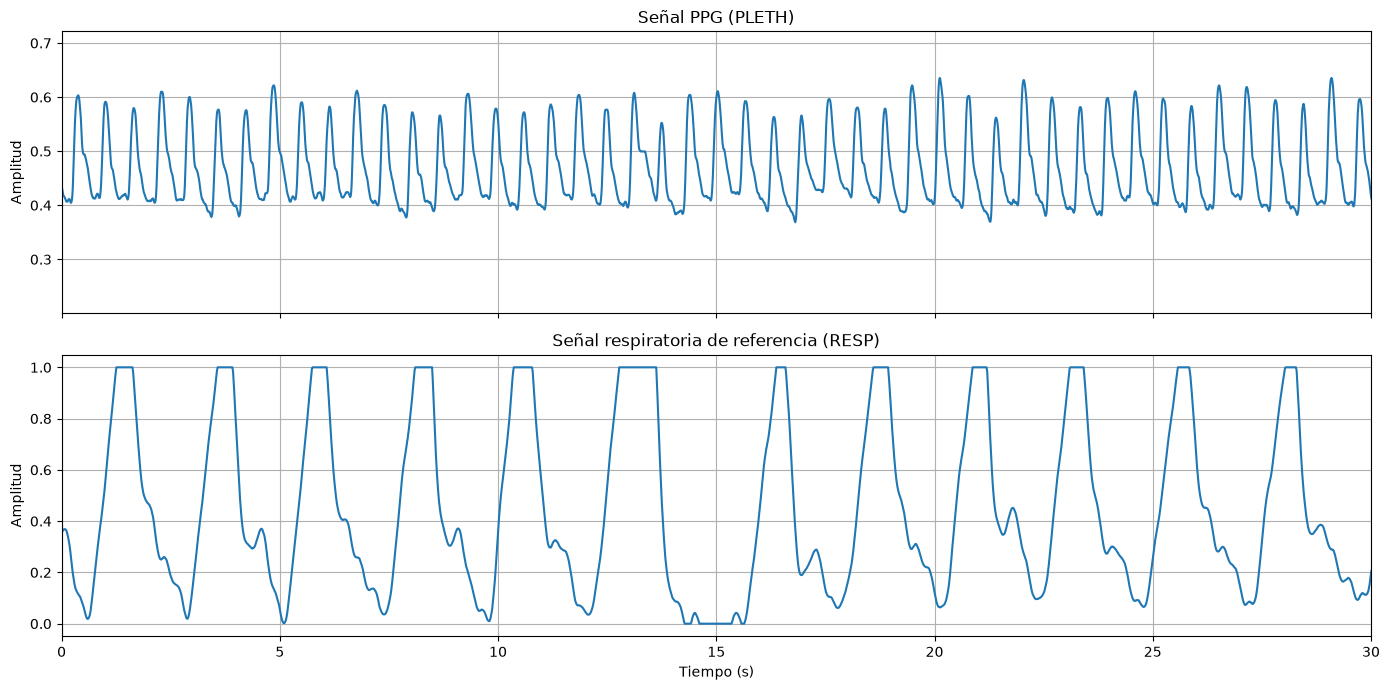

In [100]:
fs = record.fs
t = np.arange(len(signals)) / fs

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax[0].plot(t, signals["PLETH"])
ax[0].set_title("Señal PPG (PLETH)")
ax[0].set_ylabel("Amplitud")
ax[0].grid(True)

ax[1].plot(t, signals["RESP"])
ax[1].set_title("Señal respiratoria de referencia (RESP)")
ax[1].set_ylabel("Amplitud")
ax[1].set_xlabel("Tiempo (s)")
ax[1].grid(True)

plt.xlim(0, 30)
plt.tight_layout()
plt.show()

Frecuencia respiratoria estimada desde RESP: 21.00 rpm


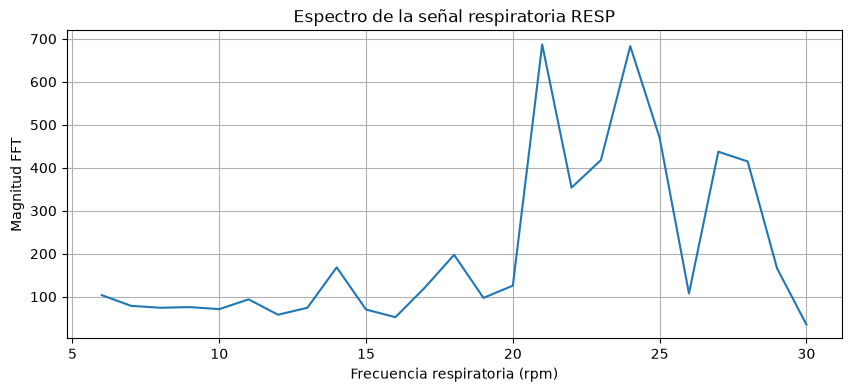

In [101]:
from scipy.signal import detrend
from scipy.fft import rfft, rfftfreq
import numpy as np
import matplotlib.pyplot as plt

# Usar los primeros 60 segundos
duracion = 60
n = int(duracion * fs)

resp = signals["RESP"].iloc[:n].to_numpy()

# Eliminar tendencia
resp = detrend(resp)

# FFT
N = len(resp)
frecuencias = rfftfreq(N, d=1/fs)
espectro = np.abs(rfft(resp))

# Banda respiratoria: 6 a 30 respiraciones/minuto
banda = (frecuencias >= 6/60) & (frecuencias <= 30/60)

f_rr = frecuencias[banda][np.argmax(espectro[banda])]
rr_referencia = f_rr * 60

print(f"Frecuencia respiratoria estimada desde RESP: {rr_referencia:.2f} rpm")

plt.figure(figsize=(10, 4))
plt.plot(frecuencias[banda] * 60, espectro[banda])
plt.xlabel("Frecuencia respiratoria (rpm)")
plt.ylabel("Magnitud FFT")
plt.title("Espectro de la señal respiratoria RESP")
plt.grid(True)
plt.show()

Número de picos detectados: 22
Frecuencia respiratoria media: 23.343140028663736 rpm
Frecuencia respiratoria mediana: 22.796352583586614 rpm
Intervalos entre respiraciones (s): [2.256 2.2   2.352 2.32  2.568 3.28  2.32  2.256 2.248 2.44  2.416 2.632
 2.704 2.648 2.896 2.808 2.696 2.888 2.872 2.784 3.072]


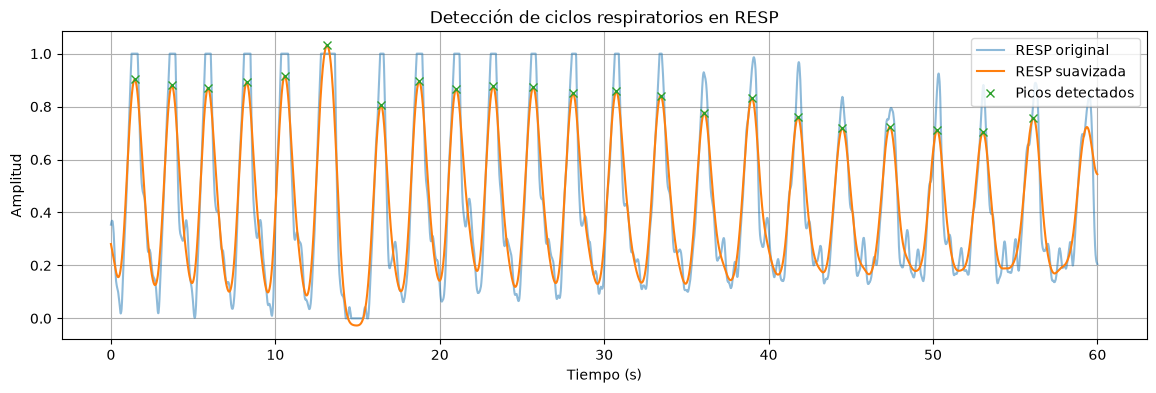

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt

# Primeros 60 segundos
duracion = 60
n = int(duracion * fs)
resp = signals["RESP"].iloc[:n].to_numpy()
t = np.arange(len(resp)) / fs

# Suavizar la señal
b, a = butter(2, 0.7 / (fs / 2), btype="low")
resp_suave = filtfilt(b, a, resp)

# Detectar máximos separados al menos 1.5 segundos
picos, _ = find_peaks(
    resp_suave,
    distance=int(1.5 * fs),
    prominence=0.2
)

# Intervalos entre respiraciones
intervalos = np.diff(t[picos])
rr_intervalos = 60 / intervalos

print("Número de picos detectados:", len(picos))
print("Frecuencia respiratoria media:", np.mean(rr_intervalos), "rpm")
print("Frecuencia respiratoria mediana:", np.median(rr_intervalos), "rpm")
print("Intervalos entre respiraciones (s):", intervalos)

plt.figure(figsize=(14, 4))
plt.plot(t, resp, alpha=0.5, label="RESP original")
plt.plot(t, resp_suave, label="RESP suavizada")
plt.plot(t[picos], resp_suave[picos], "x", label="Picos detectados")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Detección de ciclos respiratorios en RESP")
plt.grid(True)
plt.legend()
plt.show()

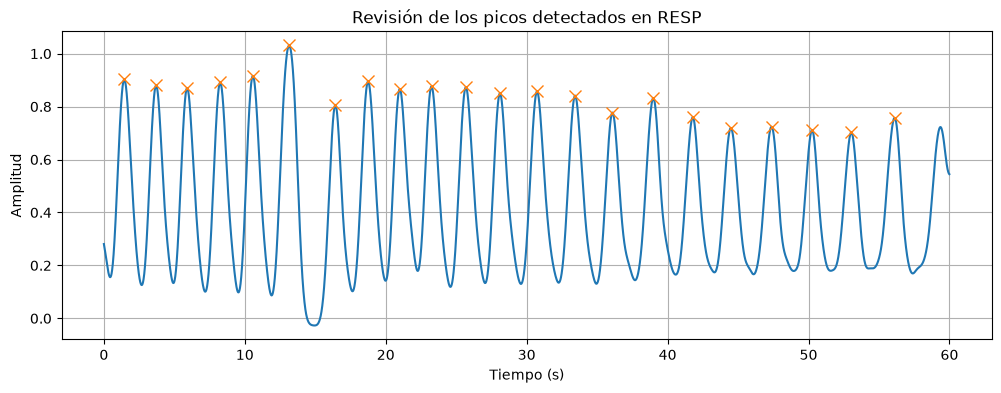

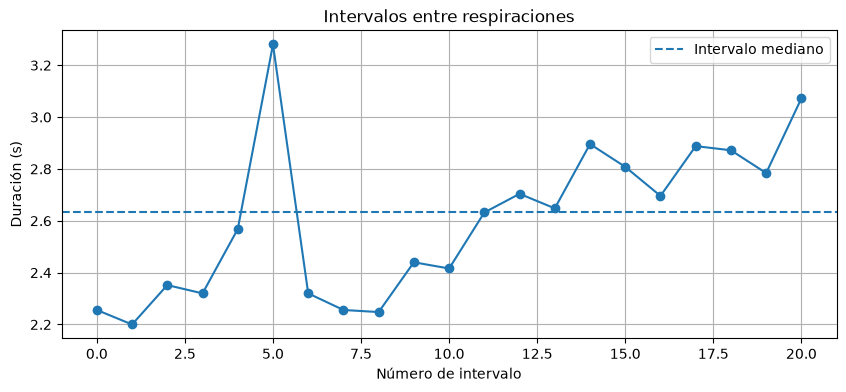

In [103]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(resp_suave)) / fs, resp_suave)
plt.plot(
    np.arange(len(resp_suave))[picos] / fs,
    resp_suave[picos],
    "x",
    markersize=8
)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Revisión de los picos detectados en RESP")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(intervalos, "o-")
plt.axhline(np.median(intervalos), linestyle="--",
            label="Intervalo mediano")
plt.xlabel("Número de intervalo")
plt.ylabel("Duración (s)")
plt.title("Intervalos entre respiraciones")
plt.grid(True)
plt.legend()
plt.show()

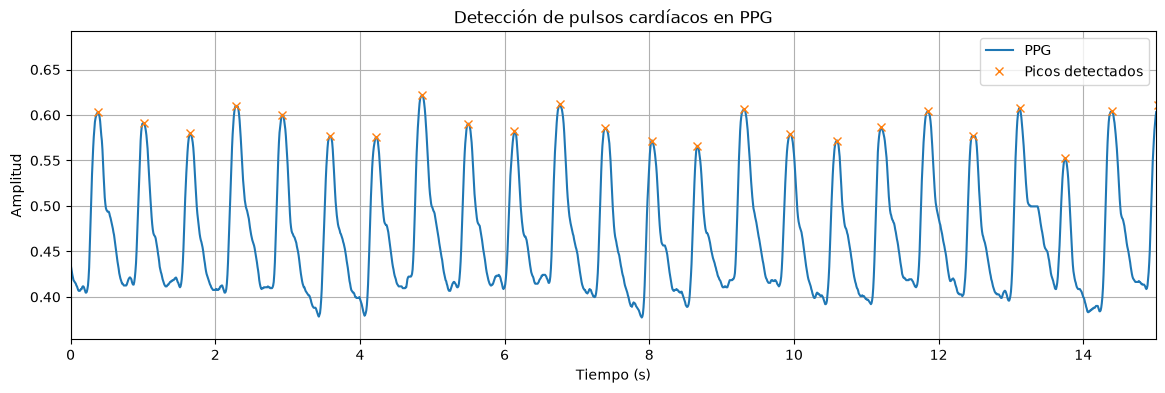

Pulsos detectados en 60 s: 91


In [104]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

ppg = signals["PLETH"].iloc[:int(60 * fs)].to_numpy()
t_ppg = np.arange(len(ppg)) / fs

# Detectar máximos de los pulsos cardíacos
peaks_ppg, _ = find_peaks(
    ppg,
    distance=int(0.4 * fs),
    prominence=0.05
)

plt.figure(figsize=(14, 4))
plt.plot(t_ppg, ppg, label="PPG")
plt.plot(t_ppg[peaks_ppg], ppg[peaks_ppg], "x",
         label="Picos detectados")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Detección de pulsos cardíacos en PPG")
plt.xlim(0, 15)
plt.grid(True)
plt.legend()
plt.show()

print("Pulsos detectados en 60 s:", len(peaks_ppg))

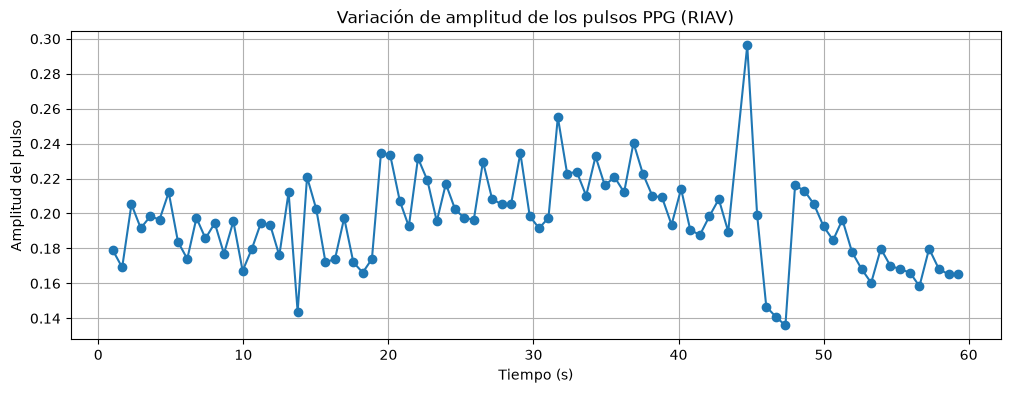

Número de amplitudes calculadas: 90


In [105]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# PPG de los primeros 60 segundos
ppg = signals["PLETH"].iloc[:int(60 * fs)].to_numpy()
t_ppg = np.arange(len(ppg)) / fs

# Detectar máximos de los pulsos
peaks_ppg, _ = find_peaks(
    ppg,
    distance=int(0.4 * fs),
    prominence=0.05
)

# Buscar el valle mínimo entre dos máximos consecutivos
amplitudes = []
tiempos_amplitud = []

for i in range(1, len(peaks_ppg)):
    inicio = peaks_ppg[i - 1]
    fin = peaks_ppg[i]

    valle = inicio + np.argmin(ppg[inicio:fin])
    amplitud = ppg[peaks_ppg[i]] - ppg[valle]

    amplitudes.append(amplitud)
    tiempos_amplitud.append(t_ppg[peaks_ppg[i]])

amplitudes = np.asarray(amplitudes)
tiempos_amplitud = np.asarray(tiempos_amplitud)

plt.figure(figsize=(12, 4))
plt.plot(tiempos_amplitud, amplitudes, "o-")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud del pulso")
plt.title("Variación de amplitud de los pulsos PPG (RIAV)")
plt.grid(True)
plt.show()

print("Número de amplitudes calculadas:", len(amplitudes))

Frecuencia respiratoria estimada desde PPG: 10.26 rpm


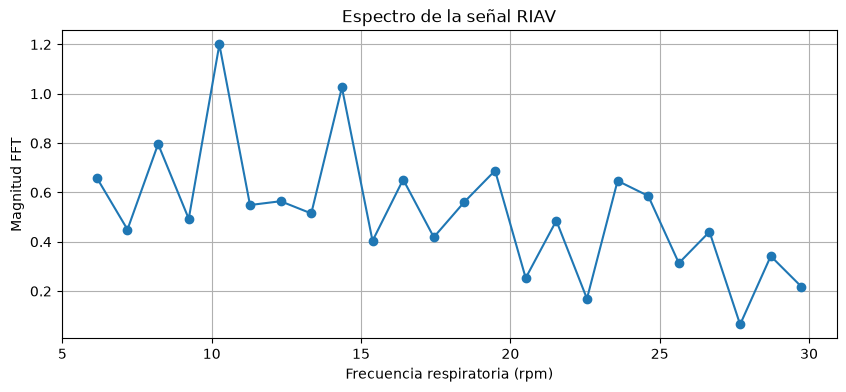

In [106]:
from scipy.interpolate import interp1d
from scipy.signal import detrend
from scipy.fft import rfft, rfftfreq
import numpy as np
import matplotlib.pyplot as plt

# Interpolar RIAV a 4 Hz
fs_riav = 4
t_uniforme = np.arange(
    tiempos_amplitud[0],
    tiempos_amplitud[-1],
    1 / fs_riav
)

interpolador = interp1d(
    tiempos_amplitud,
    amplitudes,
    kind="linear"
)

riav = interpolador(t_uniforme)

# Eliminar tendencia
riav_sin_tendencia = detrend(riav)

# FFT
N = len(riav_sin_tendencia)
frecuencias = rfftfreq(N, d=1 / fs_riav)
espectro = np.abs(rfft(riav_sin_tendencia))

# Banda respiratoria: 6–30 rpm
banda = (frecuencias >= 6 / 60) & (frecuencias <= 30 / 60)

f_rr = frecuencias[banda][np.argmax(espectro[banda])]
rr_ppg = f_rr * 60

print(f"Frecuencia respiratoria estimada desde PPG: {rr_ppg:.2f} rpm")

plt.figure(figsize=(10, 4))
plt.plot(frecuencias[banda] * 60, espectro[banda], marker="o")
plt.xlabel("Frecuencia respiratoria (rpm)")
plt.ylabel("Magnitud FFT")
plt.title("Espectro de la señal RIAV")
plt.grid(True)
plt.show()

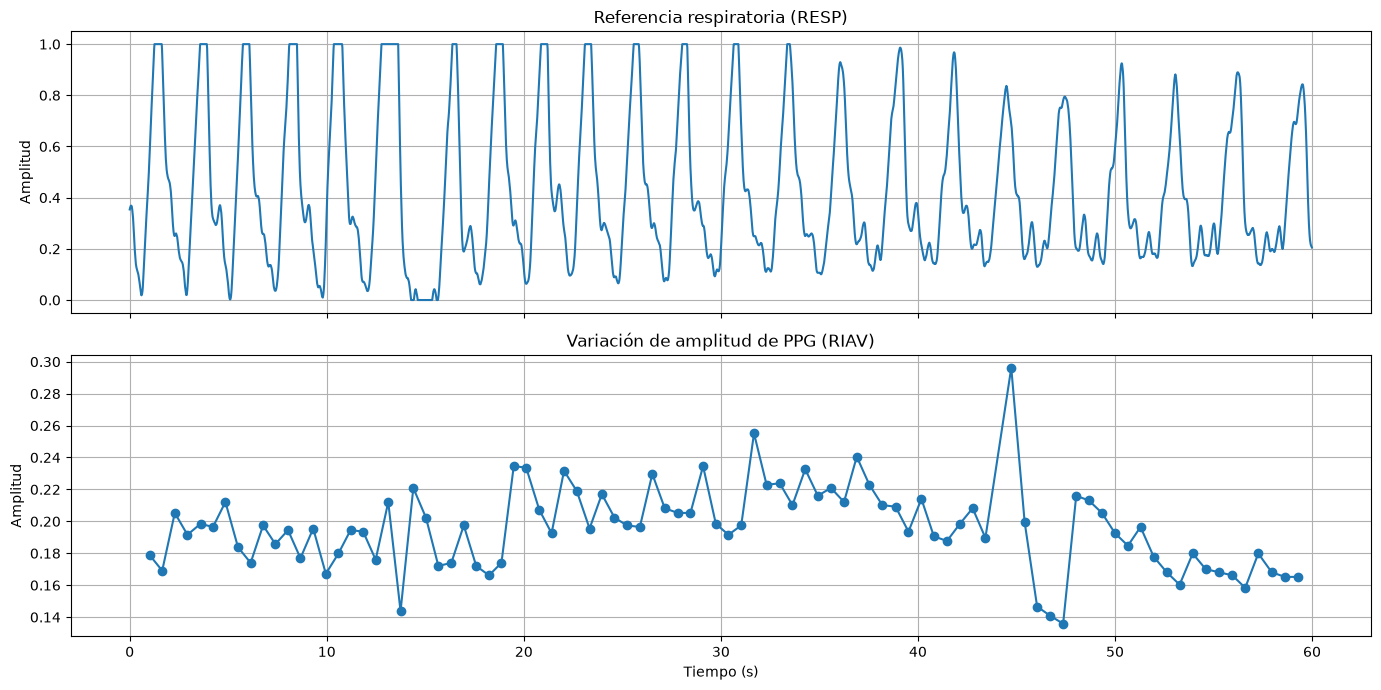

In [107]:
fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Referencia respiratoria
ax[0].plot(t, resp)
ax[0].set_title("Referencia respiratoria (RESP)")
ax[0].set_ylabel("Amplitud")
ax[0].grid(True)

# Modulación de amplitud PPG
ax[1].plot(
    tiempos_amplitud,
    amplitudes,
    "o-",
    label="RIAV"
)
ax[1].set_title("Variación de amplitud de PPG (RIAV)")
ax[1].set_ylabel("Amplitud")
ax[1].set_xlabel("Tiempo (s)")
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Línea base

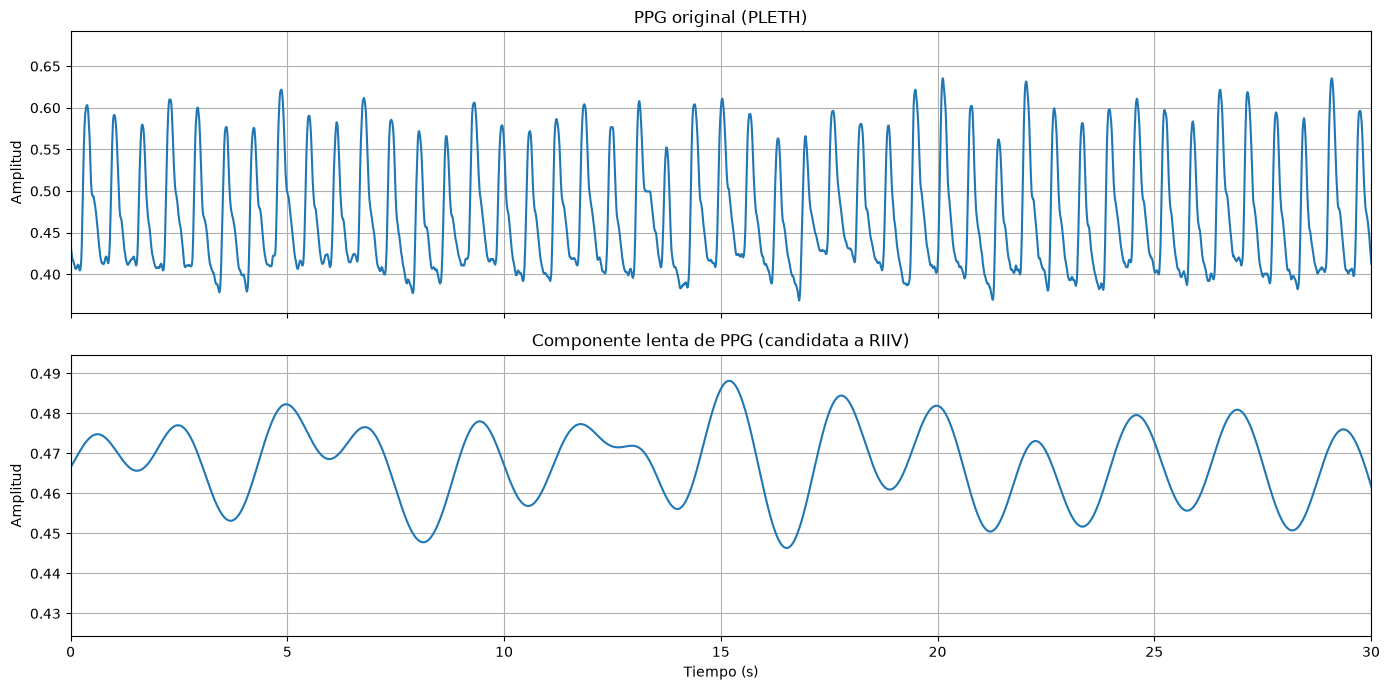

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# PPG de los primeros 60 segundos
fs = record.fs
ppg = signals["PLETH"].iloc[:int(60 * fs)].to_numpy()
t_ppg = np.arange(len(ppg)) / fs

# Filtro pasa-bajos para obtener variaciones lentas
fc = 0.5
b, a = butter(4, fc / (fs / 2), btype="low")
riiv = filtfilt(b, a, ppg)

# Comparar señal original y componente lenta
fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax[0].plot(t_ppg, ppg)
ax[0].set_title("PPG original (PLETH)")
ax[0].set_ylabel("Amplitud")
ax[0].set_xlim(0, 30)
ax[0].grid(True)

ax[1].plot(t_ppg, riiv)
ax[1].set_title("Componente lenta de PPG (candidata a RIIV)")
ax[1].set_ylabel("Amplitud")
ax[1].set_xlabel("Tiempo (s)")
ax[1].grid(True)

plt.tight_layout()
plt.show()

Frecuencia respiratoria estimada por RIIV: 24.00 rpm


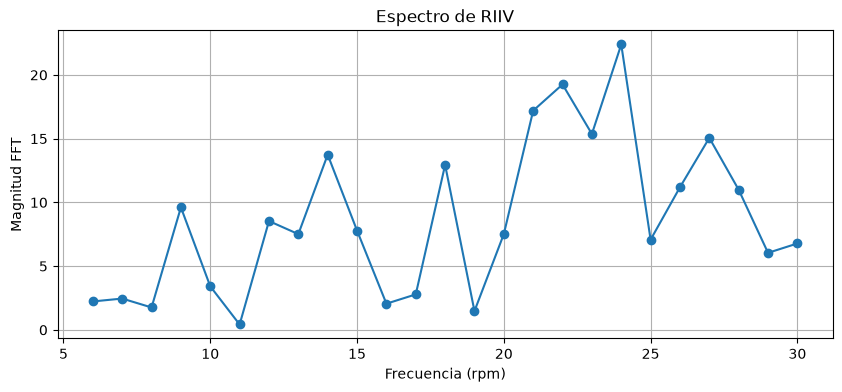

In [109]:
from scipy.signal import detrend
from scipy.fft import rfft, rfftfreq
import numpy as np
import matplotlib.pyplot as plt

# Eliminar la media y la tendencia de RIIV
riiv_proc = detrend(riiv)

# FFT
N = len(riiv_proc)
frecuencias = rfftfreq(N, d=1/fs)
espectro = np.abs(rfft(riiv_proc))

# Buscar en el rango de 6 a 30 rpm
banda = (frecuencias >= 6/60) & (frecuencias <= 30/60)

f_banda = frecuencias[banda]
e_banda = espectro[banda]

f_rr = f_banda[np.argmax(e_banda)]
rr_riiv = f_rr * 60

print(f"Frecuencia respiratoria estimada por RIIV: {rr_riiv:.2f} rpm")

plt.figure(figsize=(10, 4))
plt.plot(f_banda * 60, e_banda, marker="o")
plt.xlabel("Frecuencia (rpm)")
plt.ylabel("Magnitud FFT")
plt.title("Espectro de RIIV")
plt.grid(True)
plt.show()

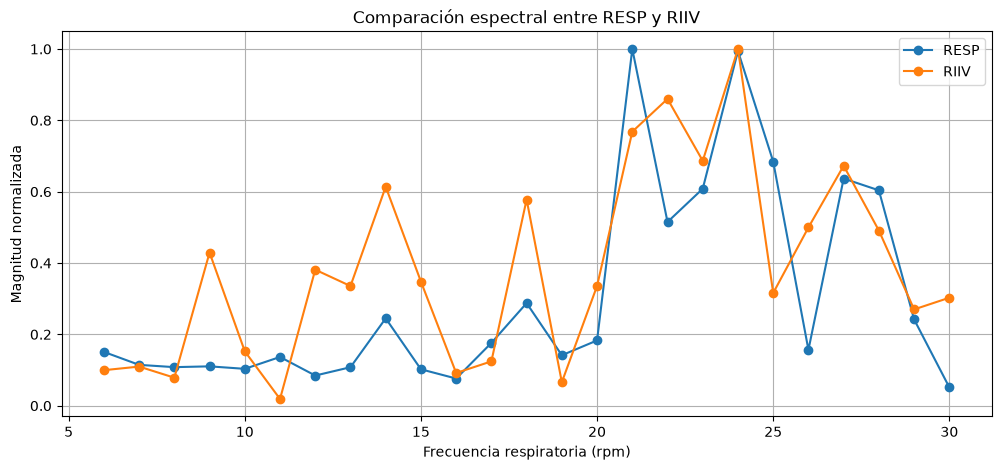

Pico dominante RESP: 21.0 rpm
Pico dominante RIIV: 24.0 rpm


In [110]:
from scipy.signal import detrend
from scipy.fft import rfft, rfftfreq
import numpy as np
import matplotlib.pyplot as plt

# Señal RESP de los mismos 60 segundos
resp = signals["RESP"].iloc[:int(60 * fs)].to_numpy()

def calcular_espectro(x, fs):
    x = detrend(x)
    N = len(x)
    f = rfftfreq(N, d=1/fs)
    espectro = np.abs(rfft(x))
    banda = (f >= 6/60) & (f <= 30/60)
    return f[banda] * 60, espectro[banda]

# Espectros de RESP y RIIV
f_resp, e_resp = calcular_espectro(resp, fs)
f_riiv, e_riiv = calcular_espectro(riiv, fs)

plt.figure(figsize=(12, 5))
plt.plot(f_resp, e_resp / np.max(e_resp), "o-", label="RESP")
plt.plot(f_riiv, e_riiv / np.max(e_riiv), "o-", label="RIIV")
plt.xlabel("Frecuencia respiratoria (rpm)")
plt.ylabel("Magnitud normalizada")
plt.title("Comparación espectral entre RESP y RIIV")
plt.grid(True)
plt.legend()
plt.show()

print("Pico dominante RESP:", f_resp[np.argmax(e_resp)], "rpm")
print("Pico dominante RIIV:", f_riiv[np.argmax(e_riiv)], "rpm")

In [111]:
from scipy.signal import detrend
from scipy.fft import rfft, rfftfreq
import numpy as np
import pandas as pd

def estimar_rr_fft(x, fs, rr_min=6, rr_max=30):
    x = detrend(np.asarray(x))
    n = len(x)

    f = rfftfreq(n, d=1/fs)
    espectro = np.abs(rfft(x))

    banda = (f >= rr_min/60) & (f <= rr_max/60)

    if not np.any(banda):
        return np.nan

    return f[banda][np.argmax(espectro[banda])] * 60

ventana_s = 30
n_ventana = ventana_s * fs
resultados = []

for inicio in range(0, 60, ventana_s):
    fin = inicio + ventana_s

    resp_ventana = signals["RESP"].iloc[
        int(inicio * fs):int(fin * fs)
    ].to_numpy()

    riiv_ventana = riiv[
        int(inicio * fs):int(fin * fs)
    ]

    resultados.append({
        "Inicio (s)": inicio,
        "Fin (s)": fin,
        "RESP (rpm)": estimar_rr_fft(resp_ventana, fs),
        "RIIV (rpm)": estimar_rr_fft(riiv_ventana, fs)
    })

pd.DataFrame(resultados)

,Inicio (s),Fin (s),RESP (rpm),RIIV (rpm)
0,0,30,24.0,24.0
1,30,60,22.0,22.0


In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend
from scipy.fft import rfft, rfftfreq

# Frecuencia de muestreo del registro
fs = record.fs

# Señales completas
ppg = signals["PLETH"].to_numpy()
resp = signals["RESP"].to_numpy()

# Comprobar duración
duracion = len(ppg) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Número de muestras: {len(ppg)}")
print(f"Duración: {duracion:.1f} s ({duracion/60:.2f} min)")
print(f"Muestras PPG ausentes: {np.isnan(ppg).sum()}")
print(f"Muestras RESP ausentes: {np.isnan(resp).sum()}")

Frecuencia de muestreo: 125 Hz
Número de muestras: 60001
Duración: 480.0 s (8.00 min)
Muestras PPG ausentes: 0
Muestras RESP ausentes: 0


In [113]:
# Parámetros
ventana_s = 30
paso_s = 10
rr_min = 6
rr_max = 30

# Extraer la componente lenta de PPG (RIIV candidata)
fc = 0.5
b, a = butter(4, fc / (fs / 2), btype="low")
riiv_completa = filtfilt(b, a, ppg)

def estimar_rr_fft(x, fs, rr_min=6, rr_max=30):
    x = detrend(np.asarray(x))
    n = len(x)

    frecuencias = rfftfreq(n, d=1/fs)
    espectro = np.abs(rfft(x))

    banda = (
        (frecuencias >= rr_min / 60) &
        (frecuencias <= rr_max / 60)
    )

    if not np.any(banda):
        return np.nan

    return frecuencias[banda][np.argmax(espectro[banda])] * 60

n_ventana = int(ventana_s * fs)
n_paso = int(paso_s * fs)

resultados = []

for inicio in range(0, len(ppg) - n_ventana + 1, n_paso):
    fin = inicio + n_ventana

    rr_ref = estimar_rr_fft(
        resp[inicio:fin], fs, rr_min, rr_max
    )

    rr_riiv = estimar_rr_fft(
        riiv_completa[inicio:fin], fs, rr_min, rr_max
    )

    resultados.append({
        "Inicio (s)": inicio / fs,
        "Fin (s)": fin / fs,
        "RESP (rpm)": rr_ref,
        "RIIV (rpm)": rr_riiv
    })

df_resultados = pd.DataFrame(resultados)
df_resultados.head(10)

,Inicio (s),Fin (s),RESP (rpm),RIIV (rpm)
0,0.0,30.0,24.0,24.0
1,10.0,40.0,24.0,24.0
2,20.0,50.0,22.0,22.0
3,30.0,60.0,22.0,22.0
4,40.0,70.0,20.0,20.0
5,50.0,80.0,20.0,20.0
6,60.0,90.0,22.0,22.0
7,70.0,100.0,22.0,10.0
8,80.0,110.0,24.0,8.0
9,90.0,120.0,22.0,8.0


In [114]:
validos = df_resultados[
    df_resultados["RESP (rpm)"].notna() &
    df_resultados["RIIV (rpm)"].notna()
].copy()

errores = (
    validos["RIIV (rpm)"] -
    validos["RESP (rpm)"]
)

mae = np.mean(np.abs(errores))
rmse = np.sqrt(np.mean(errores**2))
coincidencia = np.mean(errores == 0) * 100

print("Ventanas válidas:", len(validos))
print(f"MAE exploratorio: {mae:.2f} rpm")
print(f"RMSE exploratorio: {rmse:.2f} rpm")
print(f"Coincidencia exacta de estimaciones: {coincidencia:.1f}%")

Ventanas válidas: 46
MAE exploratorio: 1.48 rpm
RMSE exploratorio: 4.21 rpm
Coincidencia exacta de estimaciones: 82.6%


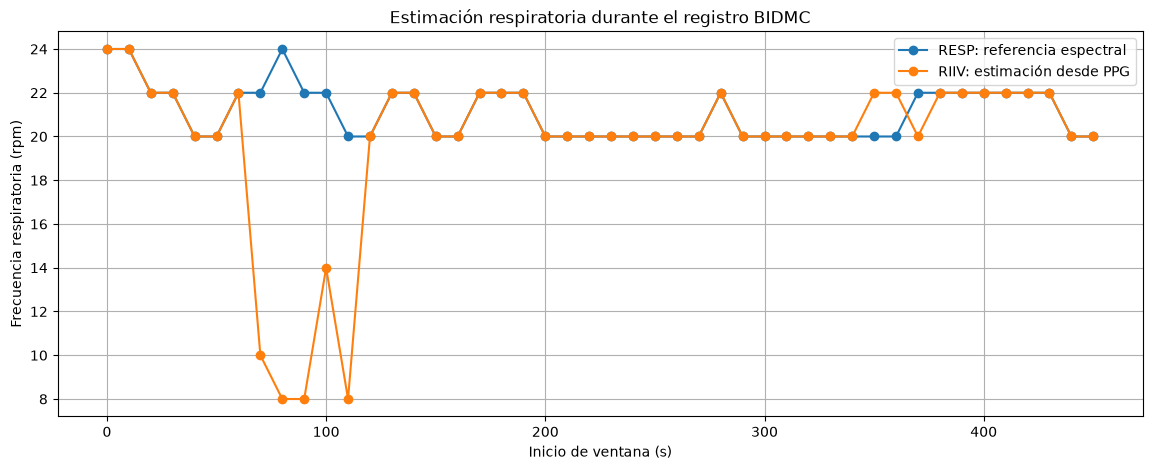

In [115]:
plt.figure(figsize=(14, 5))

plt.plot(
    df_resultados["Inicio (s)"],
    df_resultados["RESP (rpm)"],
    "o-",
    label="RESP: referencia espectral"
)

plt.plot(
    df_resultados["Inicio (s)"],
    df_resultados["RIIV (rpm)"],
    "o-",
    label="RIIV: estimación desde PPG"
)

plt.xlabel("Inicio de ventana (s)")
plt.ylabel("Frecuencia respiratoria (rpm)")
plt.title("Estimación respiratoria durante el registro BIDMC")
plt.grid(True)
plt.legend()
plt.show()

In [116]:
df_resultados["Diferencia (rpm)"] = (
    df_resultados["RIIV (rpm)"] -
    df_resultados["RESP (rpm)"]
)

df_resultados["Error absoluto (rpm)"] = (
    df_resultados["Diferencia (rpm)"].abs()
)

# Mostrar las ventanas con mayor discrepancia
df_resultados.sort_values(
    "Error absoluto (rpm)",
    ascending=False
).head(10)

,Inicio (s),Fin (s),RESP (rpm),RIIV (rpm),Diferencia (rpm),Error absoluto (rpm)
8,80.0,110.0,24.0,8.0,-16.0,16.0
9,90.0,120.0,22.0,8.0,-14.0,14.0
11,110.0,140.0,20.0,8.0,-12.0,12.0
7,70.0,100.0,22.0,10.0,-12.0,12.0
10,100.0,130.0,22.0,14.0,-8.0,8.0
37,370.0,400.0,22.0,20.0,-2.0,2.0
35,350.0,380.0,20.0,22.0,2.0,2.0
36,360.0,390.0,20.0,22.0,2.0,2.0
5,50.0,80.0,20.0,20.0,0.0,0.0
2,20.0,50.0,22.0,22.0,0.0,0.0


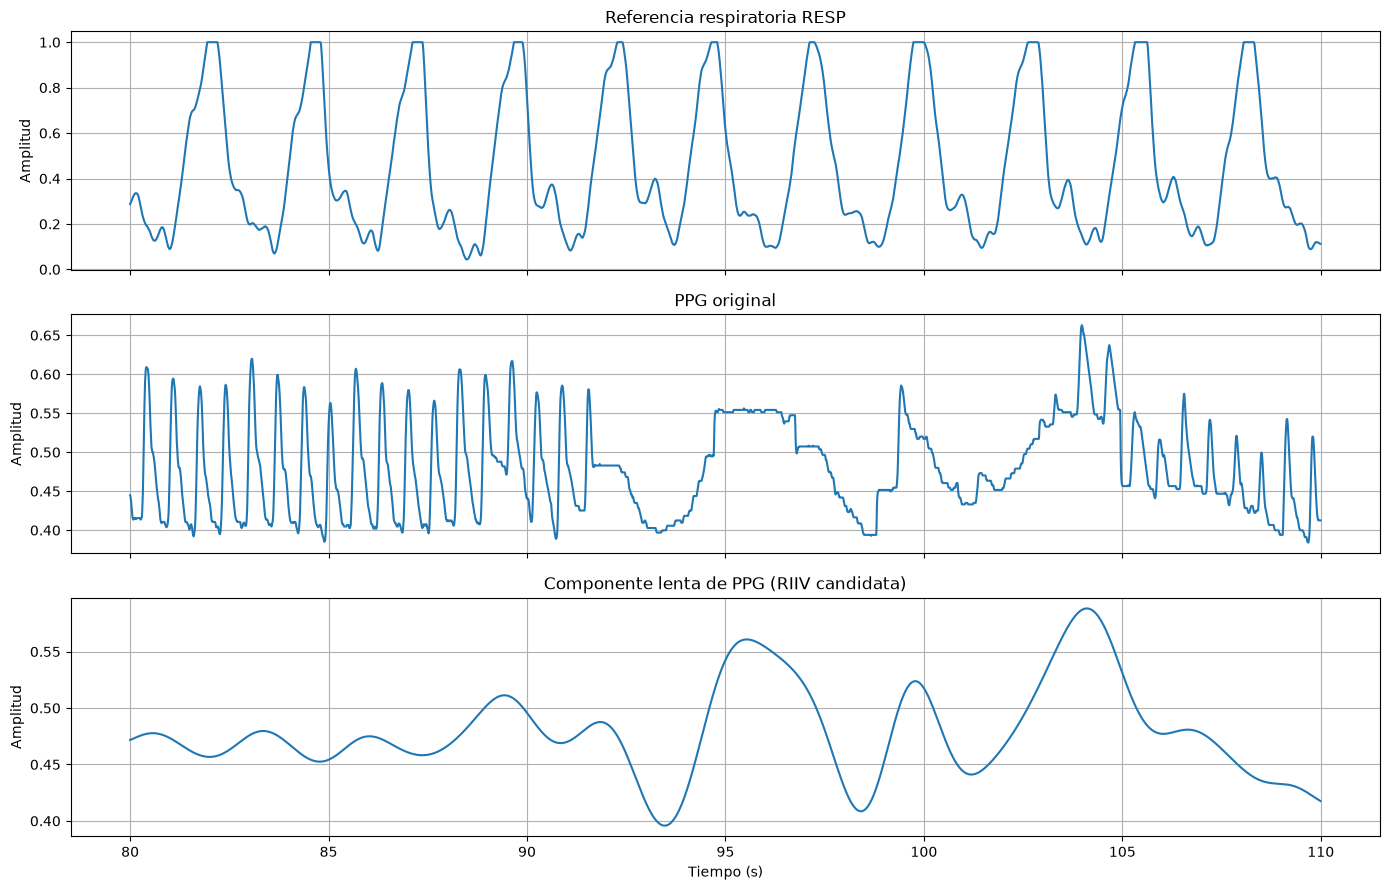

In [117]:
import matplotlib.pyplot as plt
import numpy as np

inicio_s = 80
fin_s = 110

i0 = int(inicio_s * fs)
i1 = int(fin_s * fs)

t_local = np.arange(i0, i1) / fs

fig, ax = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

ax[0].plot(t_local, signals["RESP"].iloc[i0:i1])
ax[0].set_title("Referencia respiratoria RESP")
ax[0].set_ylabel("Amplitud")
ax[0].grid(True)

ax[1].plot(t_local, ppg[i0:i1])
ax[1].set_title("PPG original")
ax[1].set_ylabel("Amplitud")
ax[1].grid(True)

ax[2].plot(t_local, riiv_completa[i0:i1])
ax[2].set_title("Componente lenta de PPG (RIIV candidata)")
ax[2].set_ylabel("Amplitud")
ax[2].set_xlabel("Tiempo (s)")
ax[2].grid(True)

plt.tight_layout()
plt.show()

In [118]:
import numpy as np
import pandas as pd

ventana_s = 30
paso_s = 10

resultados_calidad = []

for inicio in range(0, len(ppg) - int(ventana_s * fs) + 1,
                    int(paso_s * fs)):

    i0 = inicio
    i1 = inicio + int(ventana_s * fs)
    segmento = ppg[i0:i1]

    diferencias = np.abs(np.diff(segmento))
    proporcion_cambios_pequenos = np.mean(diferencias < 1e-5)

    resultados_calidad.append({
        "Inicio (s)": inicio / fs,
        "Fin (s)": i1 / fs,
        "Cambios casi nulos (%)":
            100 * proporcion_cambios_pequenos
    })

df_calidad = pd.DataFrame(resultados_calidad)
df_calidad.sort_values(
    "Cambios casi nulos (%)",
    ascending=False
).head(10)

,Inicio (s),Fin (s),Cambios casi nulos (%)
9,90.0,120.0,40.944252
8,80.0,110.0,38.757002
7,70.0,100.0,28.407575
10,100.0,130.0,25.766871
43,430.0,460.0,15.870899
11,110.0,140.0,15.817551
41,410.0,440.0,15.630835
42,420.0,450.0,15.417445
33,330.0,360.0,15.310750
32,320.0,350.0,15.124033


In [120]:
import numpy as np

referencia = df_resultados["RESP (rpm)"].to_numpy()
estimacion = df_resultados["RIIV (rpm)"].to_numpy()

valido = np.isfinite(referencia) & np.isfinite(estimacion)

error = estimacion[valido] - referencia[valido]

mae = np.mean(np.abs(error))
rmse = np.sqrt(np.mean(error**2))
sesgo = np.mean(error)

print(f"Ventanas evaluadas: {valido.sum()}")
print(f"MAE: {mae:.2f} rpm")
print(f"RMSE: {rmse:.2f} rpm")
print(f"Sesgo medio: {sesgo:.2f} rpm")

Ventanas evaluadas: 46
MAE: 1.48 rpm
RMSE: 4.21 rpm
Sesgo medio: -1.30 rpm


In [121]:
df_resultados.to_csv(
    "../data/bidmc01_riiv_fft_results.csv",
    index=False
)